In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [2]:
# Load Your Data
df = pd.read_csv("youth_data.csv")

# IRCIGFM = Imputed Revised Cigarette Frequency (Monthly), should be between 0–30
df = df[df['IRCIGFM'].between(0, 30)].copy()

In [3]:
# Feature Engineering

# SCHOOL_FAMILY captures combined influence of family and school environment
df['SCHOOL_FAMILY'] = df['PARHLPHW'] * df['SCHFELT']

# PEER_INFLUENCE combines friend-related pressures toward drug use
df['PEER_INFLUENCE'] = df['FRDMEVR2'] * df['FRDMJMON']

# Feature and Target Selection 
X = df[['PARHLPHW', 'SCHFELT', 'INCOME', 'SCHOOL_FAMILY',
        'PEER_INFLUENCE', 'YOGRPFT2', 'HEALTH2']]  # Predictors
y = df['IRCIGFM']  # Target: number of days cigarettes used in last 30 days

In [4]:
# Handle Missing Values 

# Fill missing values using mean (common for regression models)
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train-Test Split

# Split into train and test (80/20). Test helps validate final model performance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50
)

In [5]:
#  Initialize Regressor 

reg = DecisionTreeRegressor(
    max_depth=5,            # Prevents overfitting, keeps model interpretable
    min_samples_leaf=10,    # Each leaf must have at least 10 samples
    random_state=50         
)

#  Cross-Validation 
# Perform 5-fold cross-validation on training set to check generalization
cv_scores = cross_val_score(reg, X_train, y_train, cv=5, scoring='r2')
print("\n🔁 5-Fold Cross-Validation R² Scores:")
print(cv_scores)
print(f"Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")




🔁 5-Fold Cross-Validation R² Scores:
[-0.26215661 -0.00847483 -0.32120788 -0.33129251 -0.31193383]
Mean R²: -0.2470 ± 0.1216


In [6]:
# Fit Final Model 
reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=50)

In [7]:
# Make Predictions
y_pred = reg.predict(X_test)

In [8]:
#  Evaluate Model 
print("\n Evaluation on Test Set:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Approximate "accuracy" within ±0.5 days — just for interpretation
delta = 0.5
approx_accuracy = np.mean(np.abs(y_test - y_pred) <= delta)
print(f"Approximate Accuracy (±{delta} days): {approx_accuracy:.4f}")


 Evaluation on Test Set:
R² Score: -0.3625
Mean Absolute Error (MAE): 4.9706
Root Mean Squared Error (RMSE): 7.0239
Approximate Accuracy (±0.5 days): 0.1667



 Decision Tree Info:
Total Nodes in Tree: 17
Total Leaves in Tree: 9
Max Depth of Tree: 4


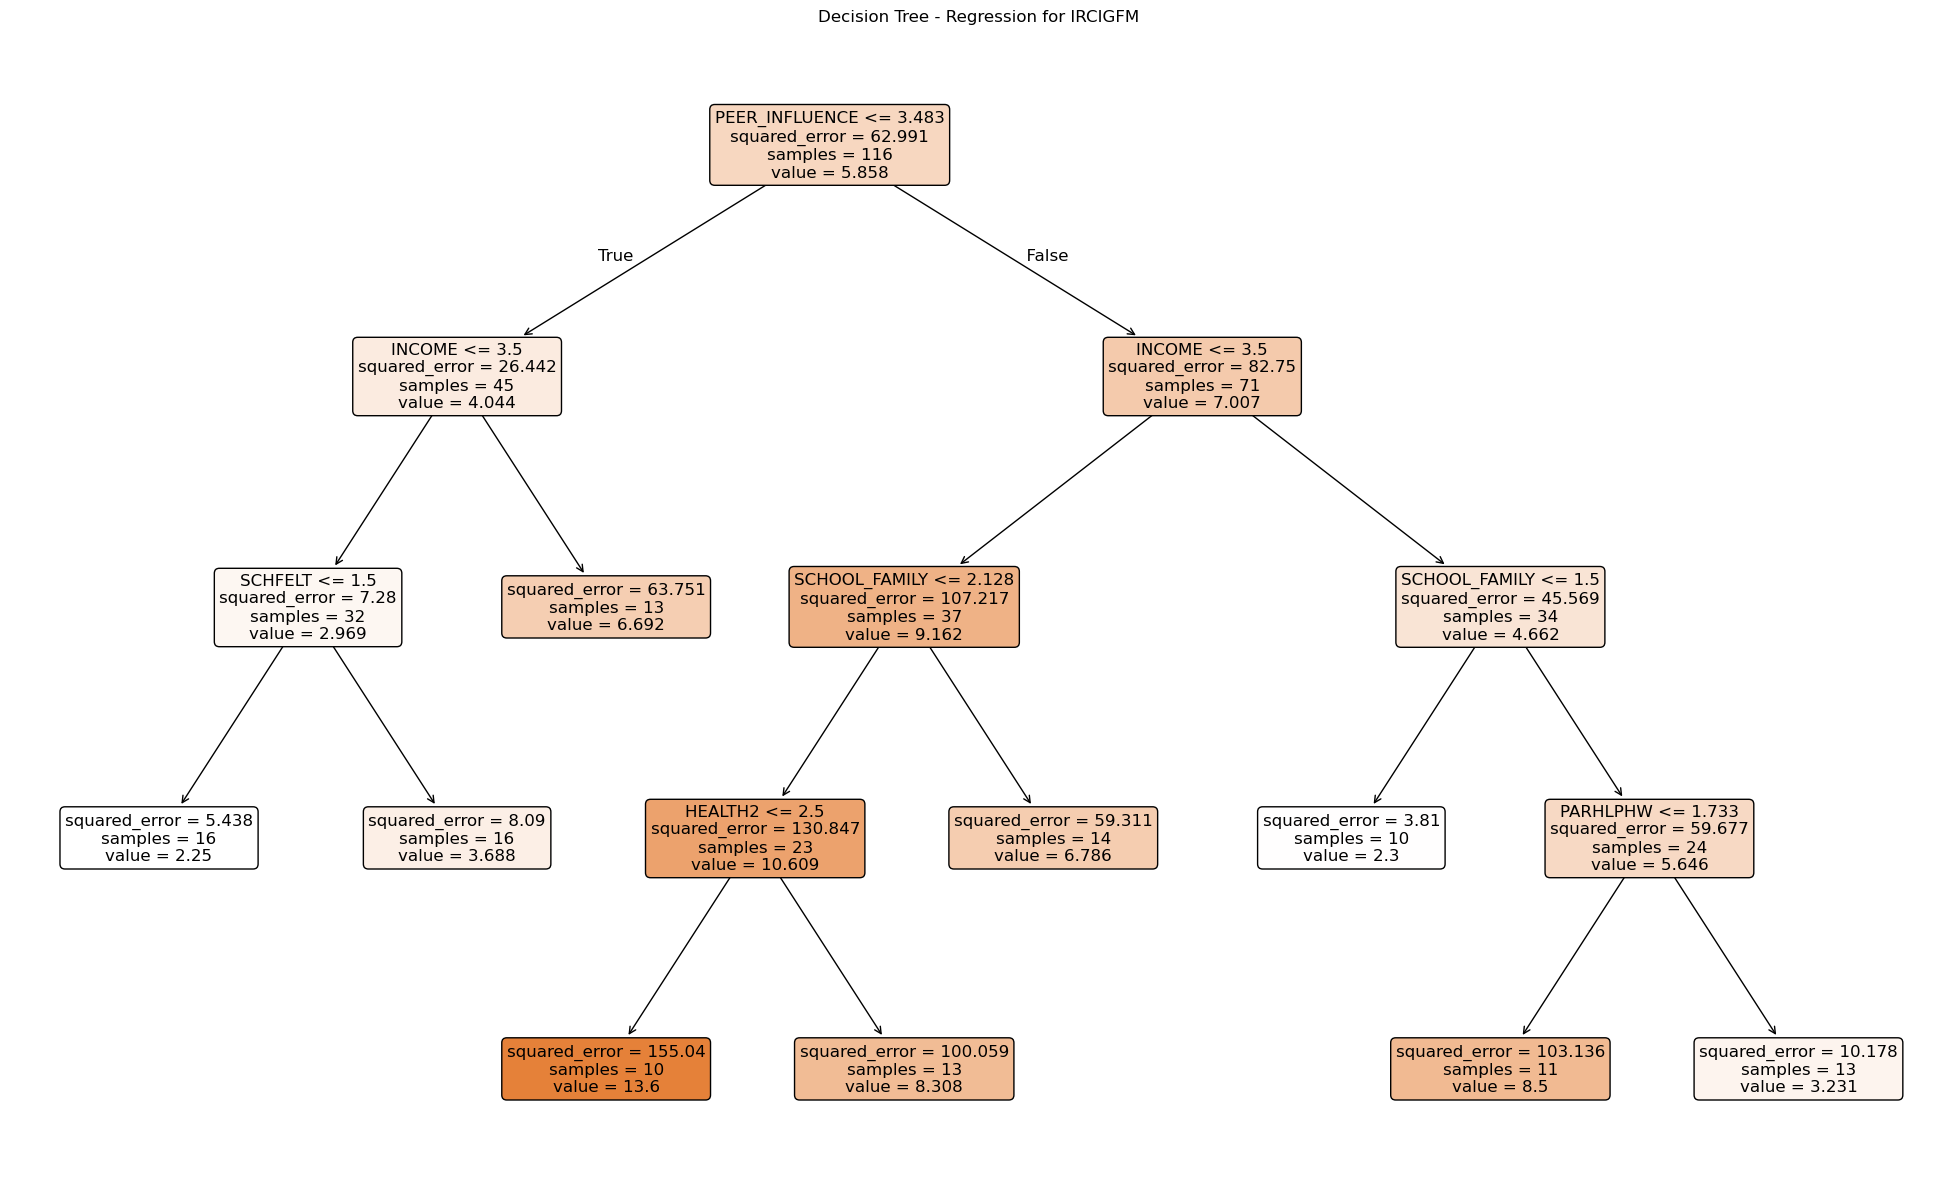

In [9]:
# Tree Structure Information 

print("\n Decision Tree Info:")
print(f"Total Nodes in Tree: {reg.tree_.node_count}")
print(f"Total Leaves in Tree: {reg.get_n_leaves()}")
print(f"Max Depth of Tree: {reg.get_depth()}")

# Visualize the Decision Tree

plt.figure(figsize=(25, 15))
plot_tree(
    reg,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree - Regression for IRCIGFM")
plt.show()


 Feature Importance:
          Feature  Importance
2          INCOME    0.381908
4  PEER_INFLUENCE    0.189565
3   SCHOOL_FAMILY    0.161702
0        PARHLPHW    0.129724
6         HEALTH2    0.124138
1         SCHFELT    0.012963
5        YOGRPFT2    0.000000


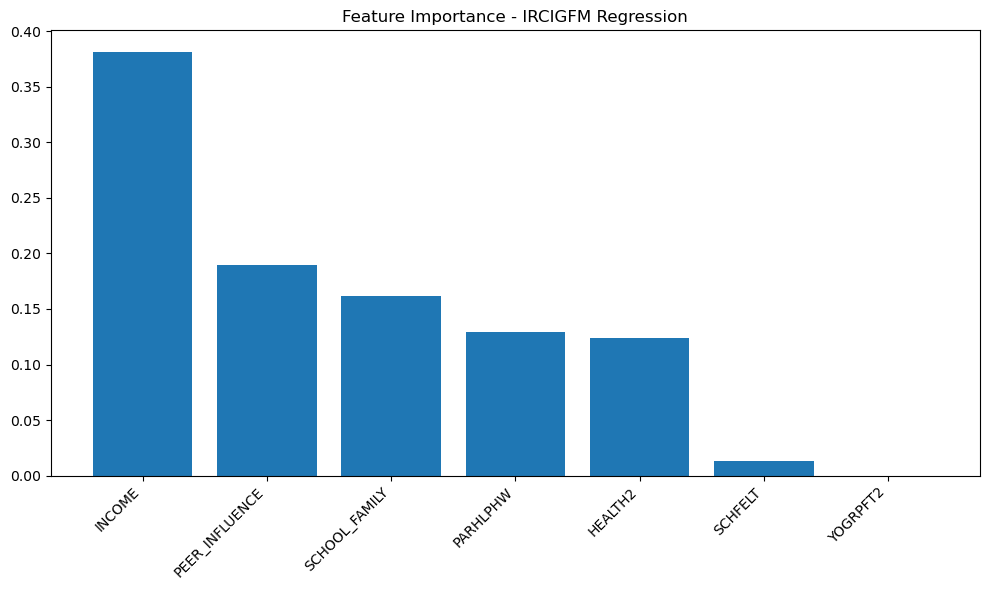

In [10]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n Feature Importance:")
print(importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=45, ha='right')
plt.title("Feature Importance - IRCIGFM Regression")
plt.tight_layout()
plt.show()

In [11]:
# In summary, the regression model sought to forecast the number of days a young person smoked throughout the previous 30 days.  Despite the poor R2 score, it provided information on important impacting factors such as income, school-family support, and peer influence.  The continuous nature of the result and the nonlinear behavior of human habits made this task more difficult.  Even though overall accuracy was low, the tree's transparency in decision rules reinforced the importance of explainability in forecasts based on health.